In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler   # u otros scalers
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet, LassoCV, RidgeCV, ElasticNetCV
from sklearn.metrics import mean_squared_error, r2_score

#### Carga de datos

In [2]:
file_path= 'uber_fares.csv'

df = pd.read_csv(file_path)

Visualización general del dataset.

In [3]:
df.head()

,key,date,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


#### Contexto  
El proyecto trata sobre **Uber Inc.**, la compañía de taxis más grande del mundo. En este trabajo, nuestro objetivo es **predecir la tarifa de futuros viajes**.  

Uber brinda servicio a millones de clientes cada día, por lo que gestionar adecuadamente sus datos es clave para desarrollar nuevas estrategias de negocio y obtener mejores resultados.  

### Variables del conjunto de datos  

**Variables explicativas:**  
- **key**: identificador único de cada viaje.  
- **pickup_datetime**: fecha y hora en que se inició el viaje.  
- **passenger_count**: cantidad de pasajeros en el vehículo (dato ingresado por el conductor).  
- **pickup_longitude**: longitud del punto de inicio del viaje.  
- **pickup_latitude**: latitud del punto de inicio del viaje.  
- **dropoff_longitude**: longitud del punto de destino.  
- **dropoff_latitude**: latitud del punto de destino.  

**Variable objetivo (target):**  
- **fare_amount**: costo del viaje en dólares.  

#### División de dataset a train y test

In [62]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns='fare_amount'), df['fare_amount'], test_size=0.2, random_state=42)

#### Examinación de estructura y contenido de variables

In [64]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 160000 entries, 153248 to 121958
Data columns (total 8 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   key                160000 non-null  int64  
 1   date               160000 non-null  object 
 2   pickup_datetime    160000 non-null  object 
 3   pickup_longitude   160000 non-null  float64
 4   pickup_latitude    160000 non-null  float64
 5   dropoff_longitude  159999 non-null  float64
 6   dropoff_latitude   159999 non-null  float64
 7   passenger_count    160000 non-null  int64  
dtypes: float64(4), int64(2), object(2)
memory usage: 11.0+ MB


Entre 160000 registros, se observan muy pocos datos nulos en las columnas relacionadas a la bajada de los viajes. Se continúa con las métricas generales de las columnas numéricas.

In [65]:
X_train.describe()

,key,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,1.600000e+05,160000.000000,160000.000000,159999.000000,159999.000000,160000.000000
mean,2.771233e+07,-72.525896,39.936265,-72.525260,39.919258,1.684988
std,1.603218e+07,11.557753,8.090121,13.611271,6.880320,1.405686
min,1.000000e+00,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,1.379326e+07,-73.992062,40.734842,-73.991433,40.733835,1.000000
50%,2.775608e+07,-73.981834,40.752594,-73.980080,40.753044,1.000000
75%,4.155845e+07,-73.967212,40.767116,-73.963614,40.768055,2.000000
max,5.542357e+07,57.418457,1644.421482,1153.572603,872.697628,208.000000


A través de este último cuadro, se destacan datos atípicos relacionados a **passenger_count**. Se observa un viaje con 208 pasajeros. Se continúa visualizando dichos valores, más los valores nulos.

**Visualización e imputación de valores atípicos**

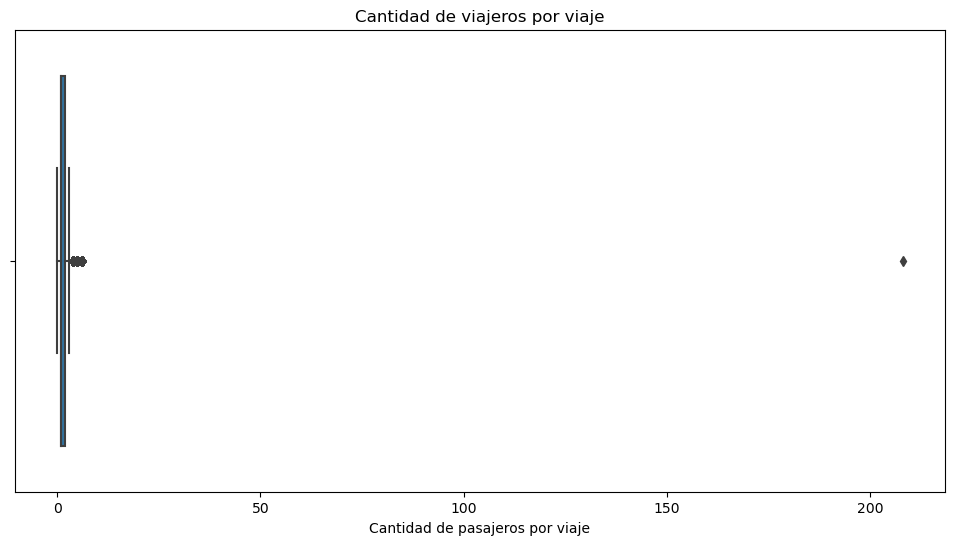

In [73]:
# Distribución de la cantidad de pasajeros por viaje (passenger_count)
plt.figure(figsize=(12,6))
sns.boxplot(x=X_train['passenger_count'])
plt.title('Cantidad de viajeros por viaje')
plt.xlabel('Cantidad de pasajeros por viaje')
plt.show()

El anterior análisis es verificado por el boxplot. Passenger_count presenta un valor máximo (y atípico) de 208 viajeros en un solo viaje. Se continúa con la observación de estos datos atípicos para luego imputarlos para los futuros modelos.

In [77]:
# Se grafica para conocer la distribución sin dicho valor atípico
df_sin_atip_pass = X_train[X_train['passenger_count']<208]

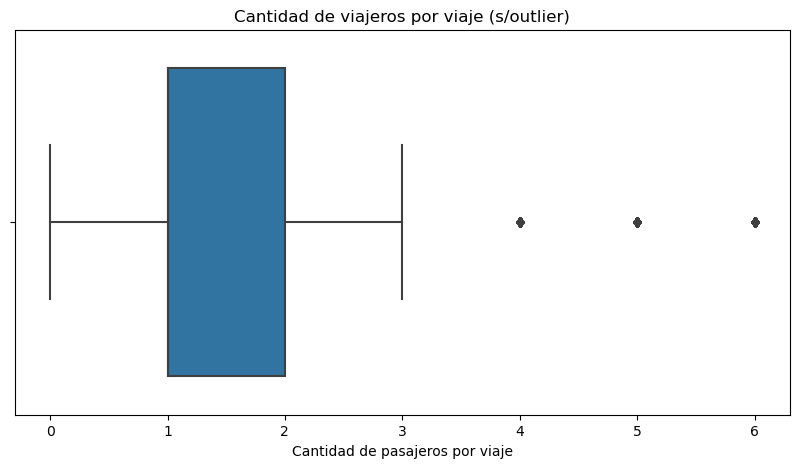

In [78]:
# Distribución passenger_count sin el outlier encontrado
plt.figure(figsize=(10, 5))
sns.boxplot(x=df_sin_atip_pass['passenger_count'])
plt.title('Cantidad de viajeros por viaje (s/outlier)')
plt.xlabel('Cantidad de pasajeros por viaje')
plt.show()

Se puede teorizar que la cantidad 0 como cantidad de pasajeros pudo ser registrados de tal forma en los casos en los que se transportó paquetería. Su valor máximo es 3 y ahora los valores atípicos se consideran más normales al ser de 4, 5 y 6 (posibles dentro de un solo auto). **Se evaluará imputar el caso encontrado con el valor de la mediana o por el outlier aceptado: 6**.

**Visualización e imputación de valores nulos**

In [80]:
# Se imprimen los valores nulos
X_train[X_train.isna().any(axis=1)]

,key,date,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
87946,32736015,2013-07-02 03:51:57.0000001,2013-07-02 03:51:57 UTC,-73.950581,40.779692,NaN,NaN,0


In [82]:
# Se elimina el valor que tenía un nulo en bajadas ya que no ayudaría en el modelo predictivo
X_train = X_train.dropna()

**Observación de variables con datos geográficos y temporales**

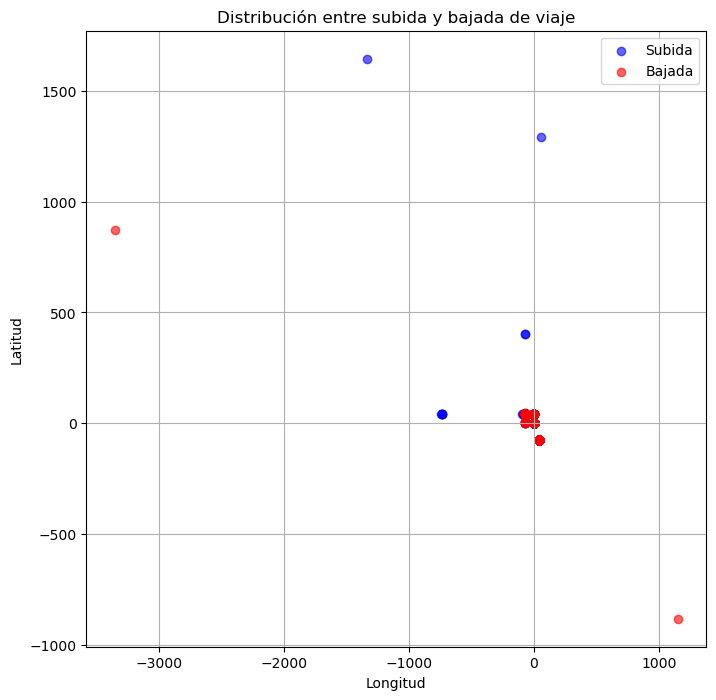

In [83]:
# Cercanía entre valores de bajada y subida de viajes
plt.figure(figsize=(8,8))
# Subida
plt.scatter(x=X_train['pickup_longitude'], y=X_train['pickup_latitude'],
            color='blue',
            label='Subida',
            alpha=0.6)

# Bajada
plt.scatter(x=X_train['dropoff_longitude'], y=X_train['dropoff_latitude'],
            color='red',
            label='Bajada',
            alpha=0.6)

plt.title('Distribución entre subida y bajada de viaje')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.grid(True)
plt.legend()
plt.show()

Se observa una posible cantidad de viajes con subidas y bajadas superpuestas (o muy ceranas). Asimismo, también parece haber viajes muy extensos con distancias muy largas. Esto obliga a crear **una variable nueva que cuente de forma clara la cantidad de KMs por viaje.**

In [84]:
# Se bien no hay valores con errores analizados previamente, se decide comparar 'date' y 'pickup_datetime'
# para chequear si presentan valores redundantes
X_train[['date', 'pickup_datetime']].head()

,date,pickup_datetime
153248,2009-11-19 21:59:00.00000086,2009-11-19 21:59:00 UTC
67802,2013-02-27 22:29:15.0000004,2013-02-27 22:29:15 UTC
148889,2014-06-01 08:48:00.00000094,2014-06-01 08:48:00 UTC
103093,2010-07-10 23:10:00.00000019,2010-07-10 23:10:00 UTC
104681,2013-09-29 13:36:00.000000167,2013-09-29 13:36:00 UTC


In [ ]:
# Al presentar valores con diferencias muy ínfimas, se decide eliminar la columna 'date' para evitar redundancia
X_train = X_train.drop('date', axis=1)

In [88]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 159999 entries, 153248 to 121958
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   key                159999 non-null  int64  
 1   pickup_datetime    159999 non-null  object 
 2   pickup_longitude   159999 non-null  float64
 3   pickup_latitude    159999 non-null  float64
 4   dropoff_longitude  159999 non-null  float64
 5   dropoff_latitude   159999 non-null  float64
 6   passenger_count    159999 non-null  int64  
dtypes: float64(4), int64(2), object(1)
memory usage: 9.8+ MB


In [89]:
# Se observa que pickup_datetime no está en su formato necesario. Se modifica a datetime
X_train['pickup_datetime'] = pd.to_datetime(X_train['pickup_datetime'], utc=True)

Se grafican los histogramas de las variables modificadas y no modificadas, para chequear diferencias u otros detalles no captados previamente.

In [91]:
df_limpio_hist = X_train[['pickup_datetime','passenger_count','pickup_longitude','pickup_latitude',
'dropoff_longitude','dropoff_latitude']]

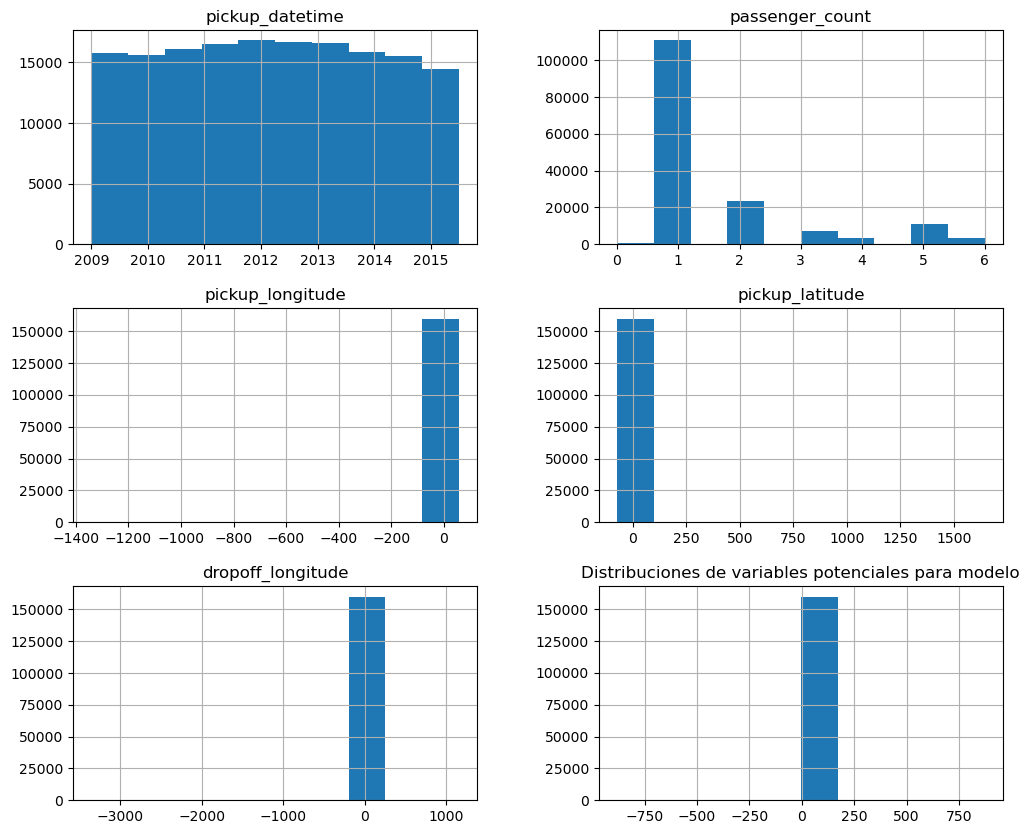

In [92]:
df_limpio_hist.hist(figsize=(12, 10))
plt.title('Distribuciones de variables potenciales para modelo')
plt.show()

**Passenger_count** y **Pickup_datetime** se consideran ya corregidas. Se procede a evaluar un poco más los longitudes y latitudes para crear la variable KMs.

**Creación de variables nuevas**

In [93]:
# Se crea una columna para conocer bien los KMs hechos por viaje
def manhattan_distance(lat1, lon1, lat2, lon2):
    R = 6371  # radio de la Tierra en km
    # Convertir a radianes
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])

    dlat = np.abs(lat2 - lat1)
    dlon = np.abs(lon2 - lon1)

    # Distancia latitudinal
    a_lat = np.sin(dlat/2.0)**2
    c_lat = 2 * np.arcsin(np.sqrt(np.clip(a_lat, 0, 1)))
    dist_lat = R * c_lat

    # Distancia longitudinal (ajustada por latitudes)
    a_lon = np.sin(dlon/2.0)**2 * np.cos(lat1) * np.cos(lat2)
    c_lon = 2 * np.arcsin(np.sqrt(np.clip(a_lon, 0, 1)))
    dist_lon = R * c_lon

    return dist_lat + dist_lon

X_train['KMs'] = manhattan_distance(
    X_train['pickup_latitude'], X_train['pickup_longitude'],
    X_train['dropoff_latitude'], X_train['dropoff_longitude'])

In [94]:
X_train['KMs'].describe()

count    159999.000000
mean         26.766088
std         500.253364
min           0.000000
25%           1.552327
50%           2.727757
75%           4.997269
max       18829.539706
Name: KMs, dtype: float64

In [95]:
# Se guardan los valores con KMs = 0 para verificar más características
df_verif_kms = X_train[X_train['KMs'] == X_train['KMs'].min()]

In [97]:
# Cantidad de Kms=0 -> 4500, se debe decidir si se imputan o eliminan
len(df_verif_kms)

4500

**RECORDATORIO: REVER KMS=0 PARA IMPUTAR**

Se agregan columnas relacionadas a días (y si el viaje se produjo un fin de semana) y horas (y si se produjo de noche o día), ya que se consideran valores importantes para el modelo predictivo buscado.

In [98]:
X_train['hour'] = X_train['pickup_datetime'].dt.hour    # variable provisaria
X_train['day'] = X_train['pickup_datetime'].dt.dayofweek    # variable provisoria
X_train['is_weekend'] = X_train['day'] >= 5     # True si es viernes, sábado o domingo
X_train['is_night'] = (X_train['hour'] >= 22) | (X_train['hour'] < 6)      # nocturno: 22 a 6

# Ideas -> se puede agregar quincena del mes; ver libreria que muestre feriados.

In [99]:
X_train.head()

,key,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,KMs,hour,day,is_weekend,is_night
153248,17778666,2009-11-19 21:59:00+00:00,-73.978585,40.748388,-73.976913,40.784958,1,4.207208,21,3,False,False
67802,54334677,2013-02-27 22:29:15+00:00,-73.978198,40.752533,-73.909752,40.874372,1,19.308079,22,2,False,True
148889,11815656,2014-06-01 08:48:00+00:00,-73.994242,40.751227,-73.999432,40.762037,1,1.639166,8,6,True,False
103093,28734805,2010-07-10 23:10:00+00:00,-73.951705,40.778330,-73.956050,40.777560,2,0.451478,23,5,True,True
104681,54482655,2013-09-29 13:36:00+00:00,-73.989120,40.736932,-73.782890,40.643947,1,27.727273,13,6,True,False


In [102]:
x_train_relevantes = X_train[['pickup_datetime', 'passenger_count', 'KMs', 'hour', 'day']]

array([[<Axes: title={'center': 'pickup_datetime'}>,
        <Axes: title={'center': 'passenger_count'}>],
       [<Axes: title={'center': 'KMs'}>,
        <Axes: title={'center': 'hour'}>],
       [<Axes: title={'center': 'day'}>, <Axes: >]], dtype=object)

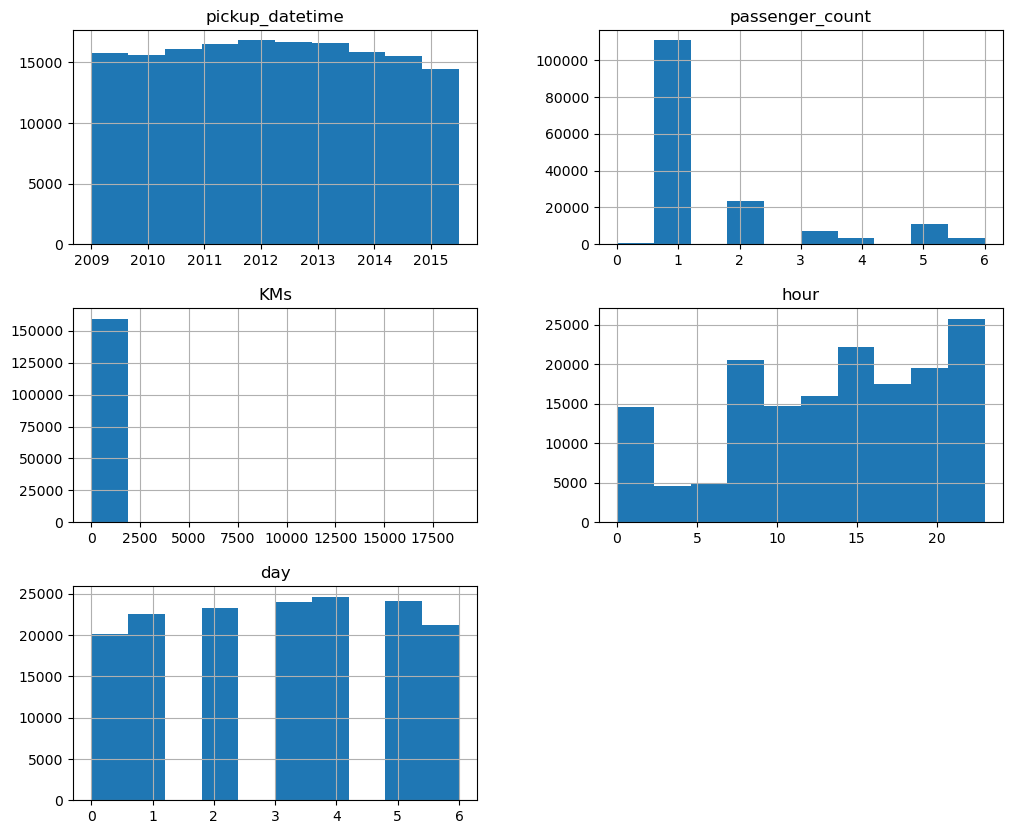

In [103]:
x_train_relevantes.hist(figsize=(12, 10))